<a href="https://colab.research.google.com/github/josephneilpadama/PADAMA_2ECEC/blob/main/2ecec_padama_exp4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_excel('board2.xlsx')

if 'Average' not in df.columns:
    df['Average'] = df[['Math', 'Electronics', 'GEAS', 'Communication']].mean(axis=1)

df.head(30)

,Name,Gender,Track,Hometown,Math,Electronics,GEAS,Communication,Average
0,S1,Male,Instrumentation,Luzon,58,89,75,78,75.00
1,S2,Female,Communication,Mindanao,52,75,90,52,67.25
2,S3,Female,Instrumentation,Mindanao,83,74,77,57,72.75
3,S4,Male,Instrumentation,Visayas,65,58,91,68,70.50
4,S5,Male,Communication,Luzon,59,86,43,88,69.00
5,S6,Female,Microelectronics,Visayas,88,45,86,83,75.50
6,S7,Female,Instrumentation,Luzon,66,60,60,48,58.50
7,S8,Male,Instrumentation,Luzon,49,81,64,53,61.75
8,S9,Male,Instrumentation,Luzon,50,36,63,42,47.75
9,S10,Male,Microelectronics,Mindanao,80,84,61,44,67.25


In [ ]:
vis_comm_filtered = df[(df['Hometown'] == 'Visayas') & (df['Track'] == 'Communication')]

VisComm = vis_comm_filtered[['Name', 'Gender', 'Math', 'Electronics', 'Average']]

print("VisComm DataFrame:")
display(VisComm)
print(f"Number of rows in VisComm: {len(VisComm)}")

VisComm DataFrame:


,Name,Gender,Math,Electronics,Average
10,S11,Female,48,56,54.75
11,S12,Male,89,67,76.00
17,S18,Male,81,40,63.50
21,S22,Female,64,39,62.50
27,S28,Male,85,53,67.75


Number of rows in VisComm: 5


In [ ]:
vis_female_filtered = df[(df['Hometown'] == 'Visayas') & (df['Gender'] == 'Female')]

VisFemale = vis_female_filtered[['Name', 'Track', 'GEAS', 'Electronics', 'Average']]

print("VisFemale DataFrame:")
display(VisFemale)

vis_female_passed = VisFemale[VisFemale['Average'] >= 60]

print("\nVisFemale Students with Average >= 60:")
display(vis_female_passed)

VisFemale DataFrame:


,Name,Track,GEAS,Electronics,Average
5,S6,Microelectronics,86,45,75.50
10,S11,Communication,48,56,54.75
20,S21,Microelectronics,68,51,68.50
21,S22,Communication,89,39,62.50
23,S24,Microelectronics,60,45,57.75
25,S26,Instrumentation,83,47,65.75



VisFemale Students with Average >= 60:


,Name,Track,GEAS,Electronics,Average
5,S6,Microelectronics,86,45,75.50
20,S21,Microelectronics,68,51,68.50
21,S22,Communication,89,39,62.50
25,S26,Instrumentation,83,47,65.75


--- Average by Track ---


,Track,Average
0,Communication,67.975
1,Instrumentation,65.225
2,Microelectronics,67.500


--- Average by Gender ---


,Gender,Average
0,Female,66.616667
1,Male,67.183333


--- Average by Hometown ---


,Hometown,Average
0,Luzon,68.083333
1,Mindanao,66.678571
2,Visayas,65.750000


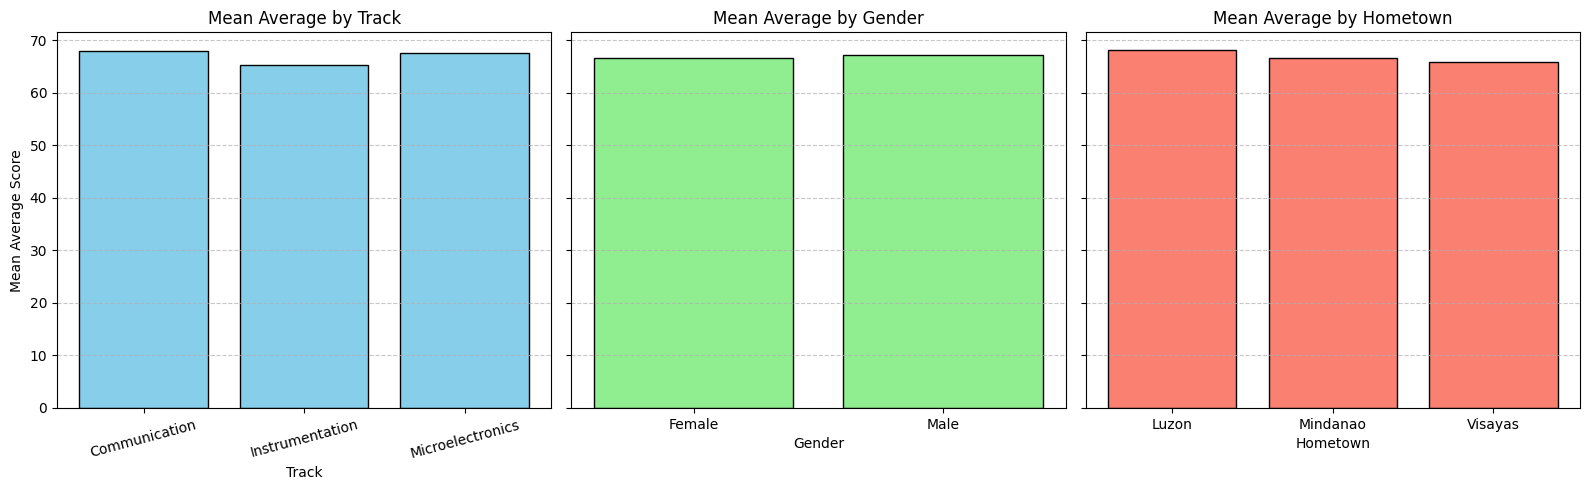

In [ ]:
track_mean = df.groupby('Track')['Average'].mean().reset_index()
gender_mean = df.groupby('Gender')['Average'].mean().reset_index()
hometown_mean = df.groupby('Hometown')['Average'].mean().reset_index()

print("--- Average by Track ---")
display(track_mean)

print("--- Average by Gender ---")
display(gender_mean)

print("--- Average by Hometown ---")
display(hometown_mean)


fig, axes = plt.subplots(1, 3, figsize=(16, 5), sharey=True)


axes[0].bar(track_mean['Track'], track_mean['Average'], color='skyblue', edgecolor='black')
axes[0].set_title('Mean Average by Track')
axes[0].set_xlabel('Track')
axes[0].set_ylabel('Mean Average Score')
axes[0].tick_params(axis='x', rotation=15)
axes[0].grid(axis='y', linestyle='--', alpha=0.7)


axes[1].bar(gender_mean['Gender'], gender_mean['Average'], color='lightgreen', edgecolor='black')
axes[1].set_title('Mean Average by Gender')
axes[1].set_xlabel('Gender')
axes[1].grid(axis='y', linestyle='--', alpha=0.7)


axes[2].bar(hometown_mean['Hometown'], hometown_mean['Average'], color='salmon', edgecolor='black')
axes[2].set_title('Mean Average by Hometown')
axes[2].set_xlabel('Hometown')
axes[2].grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()